# Sea Ice Concentration On A Projected Grid

Create a CMIP7 monthly sea-ice area percentage file (`siconc_tavg-u-hxy-u`) using the Northern Hemisphere EASE2 Lambert azimuthal equal-area grid from `data/ice_conc_nh_ease2-250_cdr-v3p1_202002.nc`.

In [1]:
from pathlib import Path
import json
import os
import shutil

os.environ.setdefault("MPLCONFIGDIR", str((Path("output") / ".matplotlib").resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str((Path("output") / ".cache").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import cmor
from IPython.display import display
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import pyproj
import xarray as xr

TABLES_DIR = "../cmip7-cmor-tables/tables"
CV_PATH = "../cmip7-cmor-tables/tables-cvs/cmor-cvs.json"
DATA_PATH = Path("data") / "ice_conc_nh_ease2-250_cdr-v3p1_202002.nc"
if not Path(TABLES_DIR).exists():
    raise FileNotFoundError(f"CMIP7 tables directory not found: {TABLES_DIR}")
if not Path(CV_PATH).exists():
    raise FileNotFoundError(f"CMIP7 CV file not found: {CV_PATH}")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Source data file not found: {DATA_PATH}")

print(f"Using CMIP7 tables from {TABLES_DIR}")

Using CMIP7 tables from ../cmip7-cmor-tables/tables


In [2]:
run_dir = Path("output") / "06_non_lat_lon_sea_ice_concentration"
if run_dir.exists():
    shutil.rmtree(run_dir)
output_dir = run_dir / "cmor_output"
output_dir.mkdir(parents=True)

DATASET_INFO = {
    "_AXIS_ENTRY_FILE": "CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": CV_PATH,
    "activity_id": "CMIP",
    "calendar": "standard",
    "drs_specs": "MIP-DRS7",
    "experiment_id": "amip",
    "forcing_index": "f3",
    "frequency": "mon",
    "grid_label": "g999",
    "host_collection": "CMIP7",
    "initialization_index": "i1",
    "institution_id": "CCCma",
    "license_id": "CC-BY-4.0",
    "mip_era": "CMIP7",
    "nominal_resolution": "25 km",
    "outpath": str(output_dir),
    "physics_index": "p1",
    "realization_index": "r9",
    "region": "nh",
    "source_id": "DUMMY-MODEL",
    "tracking_prefix": "hdl:21.14107",
}
input_json = run_dir / "input.json"
input_json.write_text(json.dumps(DATASET_INFO, indent=2, sort_keys=True))

with xr.open_dataset(DATA_PATH, decode_times=False) as opened:
    source = opened.load()

x = (source["xc"].values * 1000.0).astype("f8")
y = (source["yc"].values[::-1] * 1000.0).astype("f8")
latitude = source["lat"].values[::-1, :].T.astype("f8")
longitude = (source["lon"].values[::-1, :].T % 360.0).astype("f8")

missing_value = np.float32(1.0e20)
ice_conc = source["ice_conc"].isel(time=0).values[::-1, :].T.astype("f4")
siconc = np.where(np.isfinite(ice_conc), ice_conc, missing_value).astype("f4")[None, :, :]

time = source["time"].values.astype("f8")
time_bnds = source["time_bnds"].values.astype("f8").reshape(2)
time_units = source["time"].attrs["units"]

x_edges = np.concatenate(
    ([x[0] - 0.5 * (x[1] - x[0])], 0.5 * (x[:-1] + x[1:]), [x[-1] + 0.5 * (x[-1] - x[-2])])
)
y_edges = np.concatenate(
    ([y[0] - 0.5 * (y[1] - y[0])], 0.5 * (y[:-1] + y[1:]), [y[-1] + 0.5 * (y[-1] - y[-2])])
)

mapping_attrs = source["Lambert_Azimuthal_Grid"].attrs
crs = pyproj.CRS.from_proj4(mapping_attrs["proj4_string"])
transformer = pyproj.Transformer.from_crs(crs, crs.geodetic_crs, always_xy=True)
latitude_vertices = np.empty((*latitude.shape, 4), dtype="f8")
longitude_vertices = np.empty((*longitude.shape, 4), dtype="f8")
for vertex, (x_vertex, y_vertex) in enumerate(
    [
        (x_edges[:-1][:, None], y_edges[:-1][None, :]),
        (x_edges[1:][:, None], y_edges[:-1][None, :]),
        (x_edges[1:][:, None], y_edges[1:][None, :]),
        (x_edges[:-1][:, None], y_edges[1:][None, :]),
    ]
):
    lon_vertex, lat_vertex = transformer.transform(x_vertex, y_vertex)
    latitude_vertices[:, :, vertex] = lat_vertex
    longitude_vertices[:, :, vertex] = lon_vertex % 360.0

CRS_PARAMS = {
    "latitude_of_projection_origin": [float(mapping_attrs["latitude_of_projection_origin"]), "degrees_north"],
    "longitude_of_projection_origin": [float(mapping_attrs["longitude_of_projection_origin"]), "degrees_east"],
    "false_easting": [float(mapping_attrs["false_easting"]), "m"],
    "false_northing": [float(mapping_attrs["false_northing"]), "m"],
    "semi_major_axis": [float(mapping_attrs["semi_major_axis"]), "m"],
    "inverse_flattening": [float(mapping_attrs["inverse_flattening"]), ""],
}

print(siconc.shape, latitude.shape, latitude_vertices.shape)

(1, 432, 432) (432, 432) (432, 432, 4)


In [3]:
cmor.setup(
    inpath=TABLES_DIR,
    netcdf_file_action=cmor.CMOR_REPLACE,
    logfile=str(run_dir / "cmor.log"),
)
cmor.dataset_json(str(input_json))

grid_table = cmor.load_table("CMIP7_grids.json")
seaice_table = cmor.load_table("CMIP7_seaIce.json")

cmor.set_table(grid_table)
x_id = cmor.axis("x", coord_vals=x, units="m")
y_id = cmor.axis("y", coord_vals=y, units="m")
grid_id = cmor.grid(
    axis_ids=[x_id, y_id],
    latitude=latitude,
    longitude=longitude,
    latitude_vertices=latitude_vertices,
    longitude_vertices=longitude_vertices,
)
cmor.set_crs(grid_id, "lambert_azimuthal_equal_area", CRS_PARAMS)

cmor.set_table(seaice_table)
time_id = cmor.axis("time", coord_vals=time, cell_bounds=time_bnds, units=time_units)

variable_name = "siconc_tavg-u-hxy-u"
siconc_id = cmor.variable(variable_name, "%", [time_id, grid_id], missing_value=missing_value)
compound_name = ".".join(["seaIce"] + variable_name.split("_") + ["mon", "nh"])

with open(Path(TABLES_DIR) / "CMIP7_cell_measures.json") as handle:
    cell_measure = json.load(handle)["cell_measures"].get(compound_name)
if cell_measure:
    cmor.set_variable_attribute(siconc_id, "cell_measures", "c", cell_measure)

with open(Path(TABLES_DIR) / "CMIP7_long_name_overrides.json") as handle:
    long_name = json.load(handle)["long_name_overrides"].get(compound_name)
if long_name:
    cmor.set_variable_attribute(siconc_id, "long_name", "c", long_name)

cmor.write(siconc_id, siconc)
netcdf_path = Path(cmor.close(siconc_id, file_name=True))
cmor.close()

print(netcdf_path.resolve().relative_to(Path.cwd().resolve()))

output/06_non_lat_lon_sea_ice_concentration/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/nh/mon/siconc/tavg-u-hxy-u/g999/v20260529/siconc_tavg-u-hxy-u_mon_nh_g999_DUMMY-MODEL_amip_r9i1p1f3_202002-202002.nc


In [4]:
with xr.open_dataset(netcdf_path, decode_times=False) as opened:
    ds = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=90,
):
    display(ds)

<xarray.Dataset> Size: 16MB
Dimensions:             (time: 1, bnds: 2, x: 432, y: 432, vertices: 4)
Coordinates:
  * time                (time) float64 8B 1.539e+04
  * x                   (x) float64 3kB -5.388e+06 -5.362e+06 ... 5.388e+06
  * y                   (y) float64 3kB -5.388e+06 -5.362e+06 ... 5.388e+06
    latitude            (x, y) float64 1MB 16.62 16.82 17.02 ... 16.82 16.62
    longitude           (x, y) float64 1MB 315.0 314.9 314.7 ... 134.9 135.0
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) float64 16B 1.537e+04 1.54e+04
    crs                 int32 4B -2147483647
    vertices_latitude   (x, y, vertices) float64 6MB 16.42 16.62 ... 16.42 16.62
    vertices_longitude  (x, y, vertices) float64 6MB 315.0 315.1 ... 135.0 135.1
    siconc              (time, x, y) float32 746kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            u
    branded_variable:      siconc_tavg-u-hxy-u
    branding_suffix:       tavg-u-hxy-u
    creation_date:         2026-05-30T00:10:04Z
    data_specs_version:    MIP-DS7.1.0.0
    description:           Simulation of the climate of the recent past with ...
    drs_specs:             MIP-DRS7
    experiment:            Simulation of the climate of the recent past with ...
    experiment_id:         amip
    forcing_index:         f3
    frequency:             mon
    grid_label:            g999
    history:               2026-05-30T00:10:04Z ; CMOR rewrote data to be con...
    horizontal_label:      hxy
    host_collection:       CMIP7
    initialization_index:  i1
    institution:           Environment and Climate Change Canada
    institution_id:        CCCma
    license_id:            CC-BY-4.0
    mip_era:               CMIP7
    nominal_resolution:    25 km
    physics_index:         p1
    product:               model-output
    realization_index:     r9
    realm:                 seaIce
    region:                nh
    source:                DUMMY-MODEL: aerosol: Dummy Aerosol; atmosphere: D...
    source_id:             DUMMY-MODEL
    table_info:            Name: CMIP7_seaIce.json; Creation Date:(2026-04-21...
    temporal_label:        tavg
    title:                 DUMMY-MODEL output prepared for CMIP7
    tracking_id:           hdl:21.14107/8895eb06-4048-4a24-ae1e-a0b9b178a824
    variable_id:           siconc
    variant_label:         r9i1p1f3
    vertical_label:        u
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is license...
    cmor_version:          3.15.1

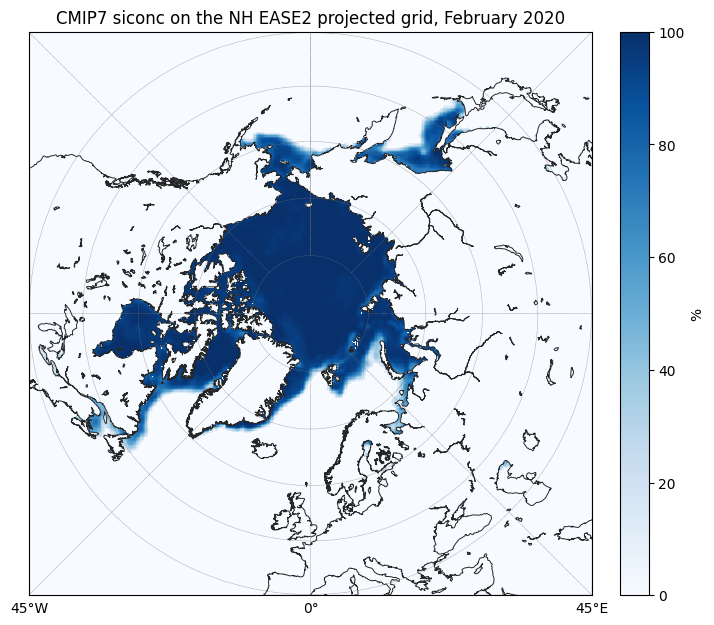

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
map_plot = Basemap(
    projection="laea",
    lat_0=90,
    lon_0=0,
    width=10_800_000,
    height=10_800_000,
    resolution="l",
    ax=ax,
)
map_plot.drawmapboundary(fill_color="#f7fbff", linewidth=0.8)
map_plot.fillcontinents(color="0.82", lake_color="#f7fbff", zorder=0)
longitude_plot = ds["longitude"].values.T
latitude_plot = ds["latitude"].values.T
field = ds["siconc"].isel(time=0).values.T
x_plot, y_plot = map_plot(longitude_plot, latitude_plot)
mesh = map_plot.pcolormesh(x_plot, y_plot, field, shading="auto", cmap="Blues", vmin=0, vmax=100)
map_plot.drawcoastlines(linewidth=0.7, color="0.15")
map_plot.drawparallels(np.arange(40, 91, 10), labels=[1, 0, 0, 0], linewidth=0.4, color="0.45", dashes=[1, 1])
map_plot.drawmeridians(np.arange(-180, 181, 45), labels=[0, 0, 0, 1], linewidth=0.4, color="0.45", dashes=[1, 1])
colorbar = map_plot.colorbar(mesh, location="right", pad="5%")
colorbar.set_label("%")
ax.set_title("CMIP7 siconc on the NH EASE2 projected grid, February 2020")
plt.show()